# Machine Learning Framework for Characterizing Marine Microbial Enzymes with Microplastic Biodegradation Potential




## 1. Import Libraries

- **pandas / numpy** — data handling and maths  
- **matplotlib / seaborn** — plotting  
- **sklearn** — machine learning models and evaluation tools  
- **imblearn** — SMOTE for handling class imbalance   
- **shap** — feature importance explanation


In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    balanced_accuracy_score, f1_score, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load the Dataset

In [148]:
df = pd.read_excel("/content/marine dataset.xlsx")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 950 rows, 9 columns


,S/N,Enzyme Name,EC Number,Source of Microbe,Temperature for Maximum Functionality,pH for Maximum Functionality,Function,Gene Encoding,Organism’s Accession Number
0,1,α-amylase,3.2.1.1,Bacillus licheniformis,50 °C,10.0,Hydrolase,amyS,X60623
1,2,Aspartic protease,3.4.23.8,Aspergillus oryzae,55 °C,4.5,Hydrolase,pepA,E02554
2,3,Xylanase,3.2.1.8,Thermoactinomyces thalophilus,60 °C,10.0,Hydrolase,xynA,AJ251779
3,4,Lipase,3.1.3.1,Acinetobacter calcoaceticus,65 °C,8.8,Hydrolase,lipA,NZ_KB849753.1
4,5,Amylase,3.2.1.1,Geobacillus sp.,65 °C,7.5,Hydrolase,Ami,KU291217.1


## 3. Exploratory Data Analysis (EDA)

Explore the raw data to understand:
- What columns there are
- What data types there are
- Whether there are missing values
- What the distribution of our target variable (Function) looks like


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 9 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   S/N                                    950 non-null    int64  
 1   Enzyme Name                            950 non-null    object 
 2   EC Number                              947 non-null    object 
 3   Source of Microbe                      950 non-null    object 
 4   Temperature for Maximum Functionality  950 non-null    object 
 5   pH for Maximum Functionality           950 non-null    float64
 6   Function                               950 non-null    object 
 7   Gene Encoding                          950 non-null    object 
 8   Organism’s Accession Number            950 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 66.9+ KB


In [150]:
df.describe(include = ["object"]).T

,count,unique,top,freq
Enzyme Name,950,591,Lipase,23
EC Number,947,448,3.2.1.81,28
Source of Microbe,950,348,Zobellia galactanivorans,31
Temperature for Maximum Functionality,950,80,30,173
Function,950,9,Hydrolase,361
Gene Encoding,950,569,katG,14
Organism’s Accession Number,950,421,CP000514,23


In [151]:
print(df.isnull().sum())

S/N                                      0
Enzyme Name                              0
EC Number                                3
Source of Microbe                        0
Temperature for Maximum Functionality    0
pH for Maximum Functionality             0
Function                                 0
Gene Encoding                            0
Organism’s Accession Number              0
dtype: int64


In [152]:
df[df.isnull().any(axis=1)]

,S/N,Enzyme Name,EC Number,Source of Microbe,Temperature for Maximum Functionality,pH for Maximum Functionality,Function,Gene Encoding,Organism’s Accession Number
80,81,Chymotrypsin-like serine protease,NaN,Thermotoga maritima,90°C,7.1,Protein degradation,enc,Q9WZP2
84,85,Quinoprotein glucose dehydrogenase B,NaN,Acinetobacter calcoaceticus,55°C,8.0,Redox reactions,gdhB,P13650
87,88,Na(+)-translocating NADH-quinone reductase sub...,NaN,Vibro aliginolyticus,37 °C,7.0,Redox reactions,nqrB,Q56587


In [153]:
df = df.dropna()

In [154]:
df.duplicated().sum()

np.int64(0)

In [155]:
df["Function"].unique()

array(['Hydrolase', 'Oxidoreductase', 'Transferase', 'Isomerase', 'Lyase',
       'Translocase', 'Ligase'], dtype=object)

In [156]:
# How many unique enzyme functions are there, and are there single classes?
vc = df['Function'].value_counts()
print(f"Total unique Function classes: {len(vc)}")
print(f"Classes with only 1 sample (singletons): {(vc == 1).sum()}")

Total unique Function classes: 7
Classes with only 1 sample (singletons): 0


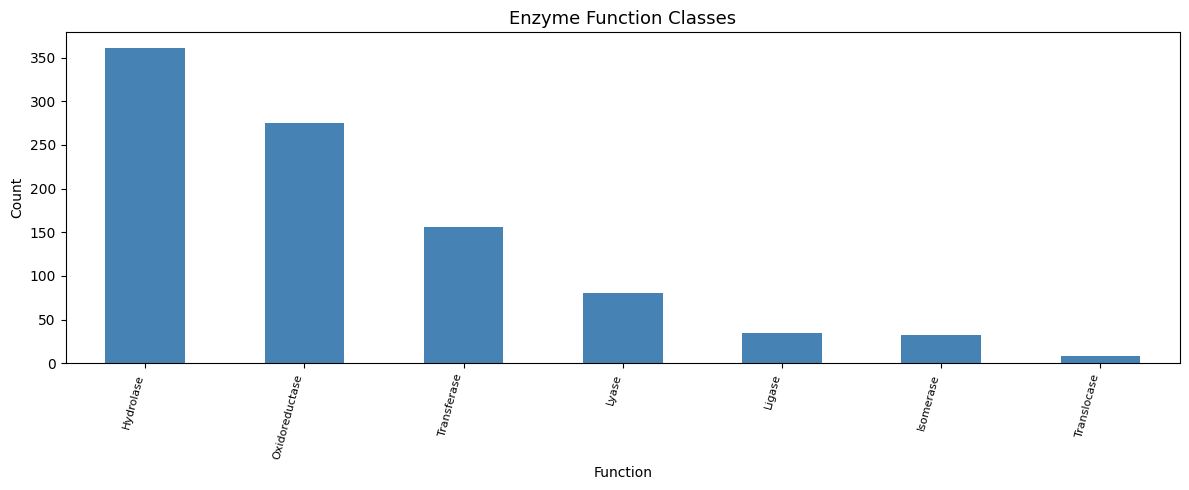

In [157]:
# Bar plot of the enzyme functions
fig, ax = plt.subplots(figsize=(12, 5))
vc.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Enzyme Function Classes', fontsize=13)
ax.set_xlabel('Function')
ax.set_ylabel('Count')
plt.xticks(rotation=75, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4.1 Clean the Temperature column

The temperature values have text like "50 °C" in them. Strip that and convert to a plain number so the model can use it.


In [158]:
# Extract numbers from strings like "50 °C" or "45°C"
df['Temperature for Maximum Functionality'] = (
    df['Temperature for Maximum Functionality']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

print("Temperature — unique values after cleaning:")
print(sorted(df['Temperature for Maximum Functionality'].dropna().unique()))

Temperature — unique values after cleaning:
[np.float64(8.0), np.float64(10.0), np.float64(12.0), np.float64(15.0), np.float64(18.0), np.float64(20.0), np.float64(22.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(37.0), np.float64(38.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(45.0), np.float64(48.0), np.float64(50.0), np.float64(53.0), np.float64(55.0), np.float64(60.0), np.float64(65.0), np.float64(70.0), np.float64(75.0), np.float64(80.0), np.float64(82.0), np.float64(83.0), np.float64(85.0), np.float64(86.0), np.float64(88.0), np.float64(90.0), np.float64(95.0)]


### 4.2 Clean the pH column

pH is already numeric in the dataset. But we convert it explicitly to be safe and round to one decimal.


In [159]:
df['pH for Maximum Functionality'] = pd.to_numeric(
    df['pH for Maximum Functionality'], errors='coerce'
)

### 4.3 Standardise organism names

Some entries refer to the same organism with slightly different spellings.
Correct them so they group properly.


In [160]:
df["Source of Microbe"].unique()

array(['Bacillus licheniformis', 'Aspergillus oryzae',
       'Thermoactinomyces thalophilus', 'Acinetobacter calcoaceticus',
       'Geobacillus sp.', 'Yeast sp.', 'Streptomyces genus',
       'Bacillus subtilis ', 'Acinetobacter sp.',
       'Actibacterium atlanticum', 'Marinobacter sp.',
       'Aspergillus niger', 'Synechococcus sp.', 'Leptoxyphium fumago',
       'Bacillus deramificans', 'Moraxella sp.', 'Nia vibrissa sp.',
       'Aliivibrio fischeri', 'Vibrio species', 'Klebsiella aerogenes',
       'Geobacter sulfurreducens', 'Clostridium histolyticum',
       'LE392 E. coli', 'Thermococcus kodakarensis',
       'Penicillium paxilli', 'Pseudomonas fluorescens',
       'Exophiala xenobiotica', 'Humicola insolens',
       'Halocyphina villosa', 'Trichoderma viride',
       'Lysobacter enzymogenes', 'Ruegeria mobilis',
       'Vibrio parahaemolyticus', 'Shewanella haliotis',
       'Fervidobacterium pennivorans', 'Thermus caldophilus',
       'Pseudomonas stutzeri', 'Alteromonas s

In [161]:
df['Source of Microbe'] = (
    df['Source of Microbe']
    .str.replace('\xa0', '', regex=False)
    .str.strip()
)

In [162]:
df['Source of Microbe'] = df['Source of Microbe'].str.lower()

In [163]:
corrections = {
    'vibro fischeri': 'vibrio fischeri',
    'thermus therrmophilus': 'thermus thermophilus',
    'penicillum citrinum': 'penicillium citrinum',
    'dino acuminata': 'dinophysis acuminata',
    'bacillus megaterium': 'bacillus megaterium',
    'leuconostoc mesenteroides ': 'leuconostoc mesenteroides'
}

df['Source of Microbe'] = df['Source of Microbe'].replace(corrections)

In [164]:
df['Source of Microbe'] = df['Source of Microbe'].str.replace(
    r'\bsp\b\.?', 'sp.', regex=True
)

In [165]:
def fix_case(name):
    return ' '.join([word.capitalize() for word in name.split()])

df['Source of Microbe'] = df['Source of Microbe'].apply(fix_case)

### 4.4 Feature engineering: split EC number into four parts

The EC number encodes a hierarchy
- **ec_1** = main reaction class
- **ec_2** = sub-class
- **ec_3** = sub-sub-class
- **ec_4** = specific enzyme serial number

By splitting it into four separate numeric features, we give the model more granular information.


In [166]:
df[['ec_1', 'ec_2', 'ec_3', 'ec_4']] = df['EC Number'].str.split('.', expand=True)

for col in ['ec_1', 'ec_2', 'ec_3', 'ec_4']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df['ec_4'].isna().sum())

# Fill missing ec_4 values with 0 (these are entries where the 4th digit was absent)
df['ec_4'].fillna(0, inplace=True)
df['ec_4'] = df['ec_4'].astype(int)

print("EC number split done.")
print(df[['ec_1','ec_2','ec_3','ec_4']].head())

54
EC number split done.
   ec_1  ec_2  ec_3  ec_4
0     3     2     1     1
1     3     4    23     8
2     3     2     1     8
3     3     1     3     1
4     3     2     1     1


### 4.5 Drop columns not needed for modelling

Remove columns that do not carry predictive signal.
Also remove EC Number now that it has been split it.


In [167]:
COLS_TO_DROP = [
    "S/N", "Enzyme Name", "Source of Microbe",
    "Gene Encoding ", "Organism’s Accession Number", "EC Number", "ec_1"
]

df = df.drop(columns=COLS_TO_DROP)

print("Remaining columns:", df.columns.tolist())
print("Dataset shape after column removal:", df.shape)

Remaining columns: ['Temperature for Maximum Functionality', 'pH for Maximum Functionality', 'Function', 'ec_2', 'ec_3', 'ec_4']
Dataset shape after column removal: (947, 6)


### 4.6 Convert all numeric columns to integers




In [168]:
df['Temperature for Maximum Functionality'] = df['Temperature for Maximum Functionality'].round().astype(int)
df['pH for Maximum Functionality'] = df['pH for Maximum Functionality'].round().astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947 entries, 0 to 949
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Temperature for Maximum Functionality  947 non-null    int64 
 1   pH for Maximum Functionality           947 non-null    int64 
 2   Function                               947 non-null    object
 3   ec_2                                   947 non-null    int64 
 4   ec_3                                   947 non-null    int64 
 5   ec_4                                   947 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 51.8+ KB


## 5. Class Distribution Analysis

### 5.1 View Enzyme Function Distribution After Cleaning


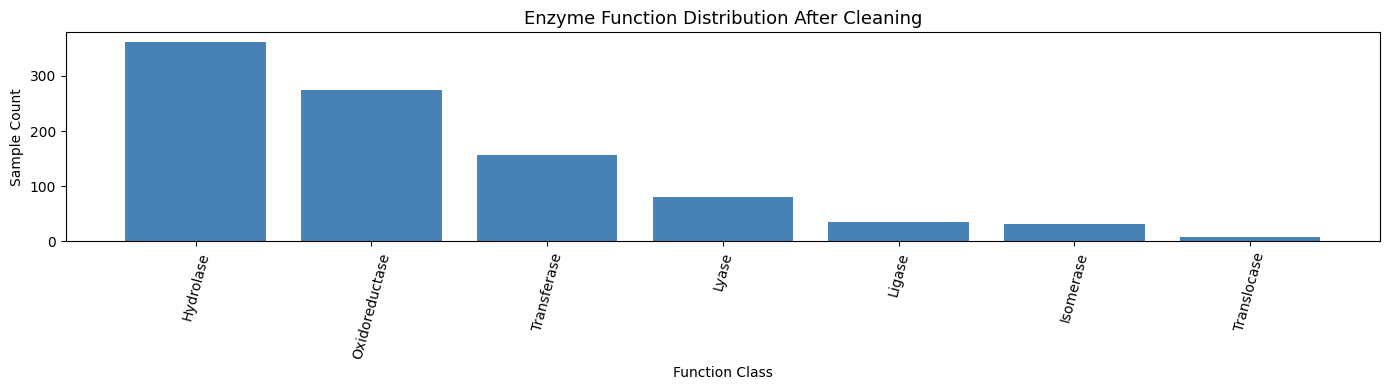

In [169]:
vc_clean = df['Function'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(vc_clean.index, vc_clean.values, color='steelblue')

ax.set_title('Enzyme Function Distribution After Cleaning', fontsize=13)
ax.set_xlabel('Function Class')
ax.set_ylabel('Sample Count')

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### 5.2 Encode the target variable

Convert Function from text to numbers. Keep a dictionary so we can decode the numbers
back to names when reading results.


In [170]:
le = LabelEncoder()
df['Function'] = le.fit_transform(df['Function'])

# Build a lookup dictionary: encoded number → original function name
label_map = dict(zip(le.transform(le.classes_), le.classes_))

print(f"Number of classes after encoding: {len(le.classes_)}")
print()
print("Label map:")
for k, v in list(label_map.items())[:10]:
    print(f"  {k:3d}  →  {v}")

Number of classes after encoding: 7

Label map:
    0  →  Hydrolase
    1  →  Isomerase
    2  →  Ligase
    3  →  Lyase
    4  →  Oxidoreductase
    5  →  Transferase
    6  →  Translocase


## 6. Feature Correlation Heatmap

We check whether any features are strongly correlated with each other.
High correlation between features can sometimes reduce model performance or make interpretation harder.


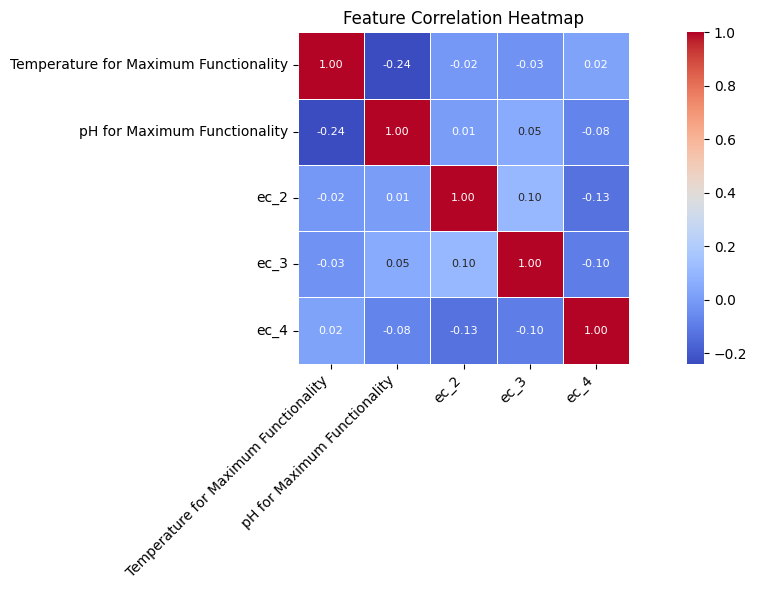

In [171]:
num_cols = df.select_dtypes(include=['int64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'Function']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 8},
    square=True
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title('Feature Correlation Heatmap', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Train/Test Split

Split 80% of the data for training and 20% for testing.
`stratify=y` ensures that the proportion of each class is the same in both splits.
This prevents a situation where some classes end up entirely in training or entirely in testing.


In [172]:
X = df.drop(columns=['Function'])
y = df['Function']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Features used    : {X.columns.tolist()}")

Training samples : 757
Test samples     : 190
Features used    : ['Temperature for Maximum Functionality', 'pH for Maximum Functionality', 'ec_2', 'ec_3', 'ec_4']


## 8. Handling Class Imbalance with SMOTE

In [173]:
# Apply SMOTE to training set only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train.astype('float64'), y_train)

print("    Class distribution BEFORE SMOTE (training set) ===")
before = pd.Series(y_train).value_counts().sort_values(ascending=False)
print(before.head(15))

print(f"\nTotal training samples before SMOTE: {len(y_train)}")

print("\n   Class distribution AFTER SMOTE (training set)")
after = pd.Series(y_train_resampled).value_counts().sort_values(ascending=False)
print(after.head(15))

print(f"\nTotal training samples after SMOTE: {len(y_train_resampled)}")

    Class distribution BEFORE SMOTE (training set) ===
Function
0    288
4    220
5    125
3     64
2     28
1     26
6      6
Name: count, dtype: int64

Total training samples before SMOTE: 757

   Class distribution AFTER SMOTE (training set)
Function
3    288
5    288
0    288
4    288
1    288
2    288
6    288
Name: count, dtype: int64

Total training samples after SMOTE: 2016


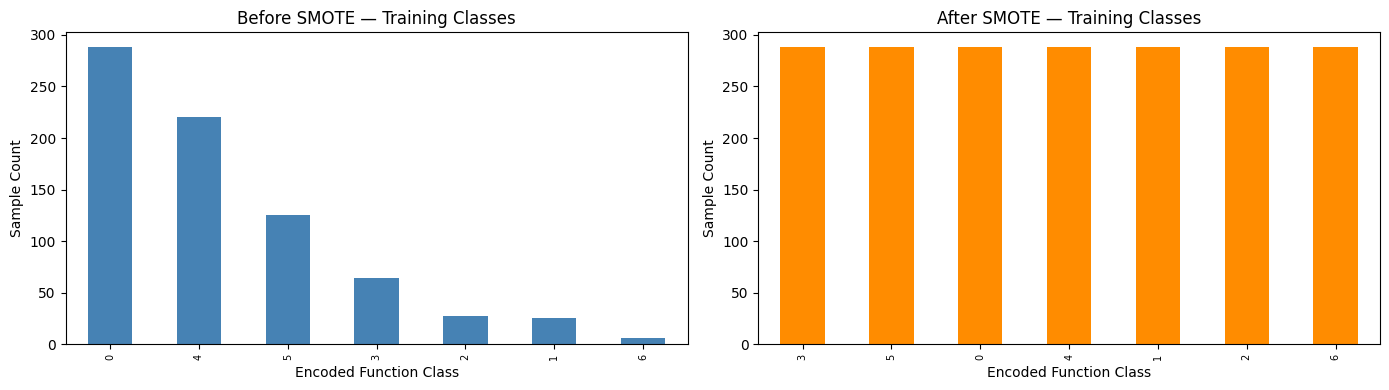

In [174]:
# Side-by-side bar chart: before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

before.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Before SMOTE — Training Classes')
axes[0].set_xlabel('Encoded Function Class')
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', labelsize=7)

after.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('After SMOTE — Training Classes')
axes[1].set_xlabel('Encoded Function Class')
axes[1].set_ylabel('Sample Count')
axes[1].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()

## 9. Helper Function for Evaluation

In [175]:
def evaluate_model(model, model_name, X_tr, y_tr, X_te, y_te, use_smote=True):
    """
    Train a model, run cross-validation, evaluate on test set,
    and plot a confusion matrix.

    Parameters
    ----------
    model       : sklearn estimator
    model_name  : str, for display
    X_tr, y_tr  : training features and labels
    X_te, y_te  : test features and labels
    use_smote   : if True, uses SMOTE-resampled training data
    """

    if use_smote:
        Xt, yt = X_tr.astype('float64'), y_tr
        smote_local = SMOTE(random_state=42, k_neighbors=5)
        Xt, yt = smote_local.fit_resample(Xt, yt)
    else:
        Xt, yt = X_tr.astype('float64'), y_tr

    # Cross-validation (stratified 5-fold)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_res = cross_validate(
        model, Xt, yt, cv=skf,
        scoring=['balanced_accuracy', 'f1_macro'],
        return_train_score=False
    )

    print("\n")
    print(f"  MODEL: {model_name}  ({'with' if use_smote else 'without'} SMOTE)")
    print("\n    5-Fold Cross-Validation (on training set)    ")
    print(f"  Balanced Accuracy : {np.mean(cv_res['test_balanced_accuracy']):.3f}"
          f" ± {np.std(cv_res['test_balanced_accuracy']):.3f}")
    print(f"  Macro F1          : {np.mean(cv_res['test_f1_macro']):.3f}"
          f" ± {np.std(cv_res['test_f1_macro']):.3f}")

    # Fit on full (resampled) training set, evaluate on test set
    model.fit(Xt, yt)
    y_pred = model.predict(X_te.astype('float64'))

    print("\n    Test Set Performance    ")
    print(f"  Accuracy          : {accuracy_score(y_te, y_pred):.3f}")
    print(f"  Balanced Accuracy : {balanced_accuracy_score(y_te, y_pred):.3f}")
    print(f"  Macro F1          : {f1_score(y_te, y_pred, average='macro', zero_division=0):.3f}")
    print(f"  Weighted F1       : {f1_score(y_te, y_pred, average='weighted', zero_division=0):.3f}")

    print("\n    Full Classification Report    ")
    print(classification_report(y_te, y_pred, zero_division=0))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = confusion_matrix(y_te, y_pred, labels=np.unique(yt))
    disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(yt))
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'Confusion Matrix — {model_name} ({"with" if use_smote else "without"} SMOTE)')
    plt.tight_layout()
    plt.show()

    return model, y_pred

print("evaluate_model() function defined.")

evaluate_model() function defined.


## 10. Gradient Boosting Classifier Model



  MODEL: Gradient Boosting  (with SMOTE)

    5-Fold Cross-Validation (on training set)    
  Balanced Accuracy : 0.867 ± 0.011
  Macro F1          : 0.867 ± 0.011

    Test Set Performance    
  Accuracy          : 0.753
  Balanced Accuracy : 0.595
  Macro F1          : 0.572
  Weighted F1       : 0.758

    Full Classification Report    
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        73
           1       0.33      0.50      0.40         6
           2       0.56      0.71      0.62         7
           3       0.62      0.62      0.62        16
           4       0.76      0.76      0.76        55
           5       0.72      0.74      0.73        31
           6       0.00      0.00      0.00         2

    accuracy                           0.75       190
   macro avg       0.56      0.60      0.57       190
weighted avg       0.77      0.75      0.76       190



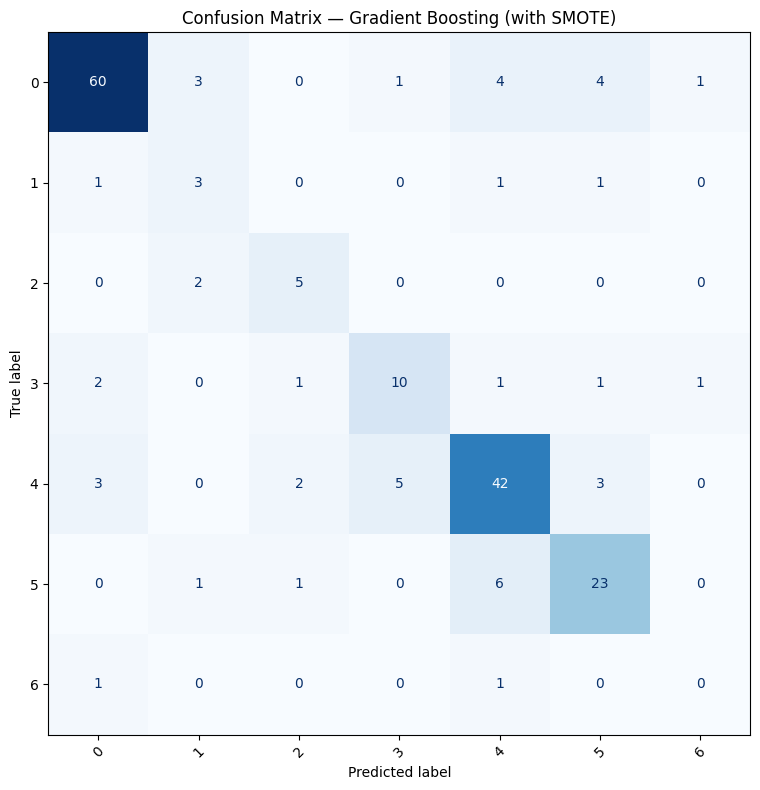

In [176]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_fitted, gb_preds = evaluate_model(
    gb_model, "Gradient Boosting",
    X_train, y_train, X_test, y_test,
    use_smote=True
)

## 11. Random Forest Classifier Model



  MODEL: Random Forest  (with SMOTE)

    5-Fold Cross-Validation (on training set)    
  Balanced Accuracy : 0.894 ± 0.006
  Macro F1          : 0.893 ± 0.006

    Test Set Performance    
  Accuracy          : 0.779
  Balanced Accuracy : 0.591
  Macro F1          : 0.567
  Weighted F1       : 0.783

    Full Classification Report    
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        73
           1       0.33      0.50      0.40         6
           2       0.40      0.57      0.47         7
           3       0.67      0.62      0.65        16
           4       0.86      0.80      0.83        55
           5       0.73      0.77      0.75        31
           6       0.00      0.00      0.00         2

    accuracy                           0.78       190
   macro avg       0.55      0.59      0.57       190
weighted avg       0.79      0.78      0.78       190



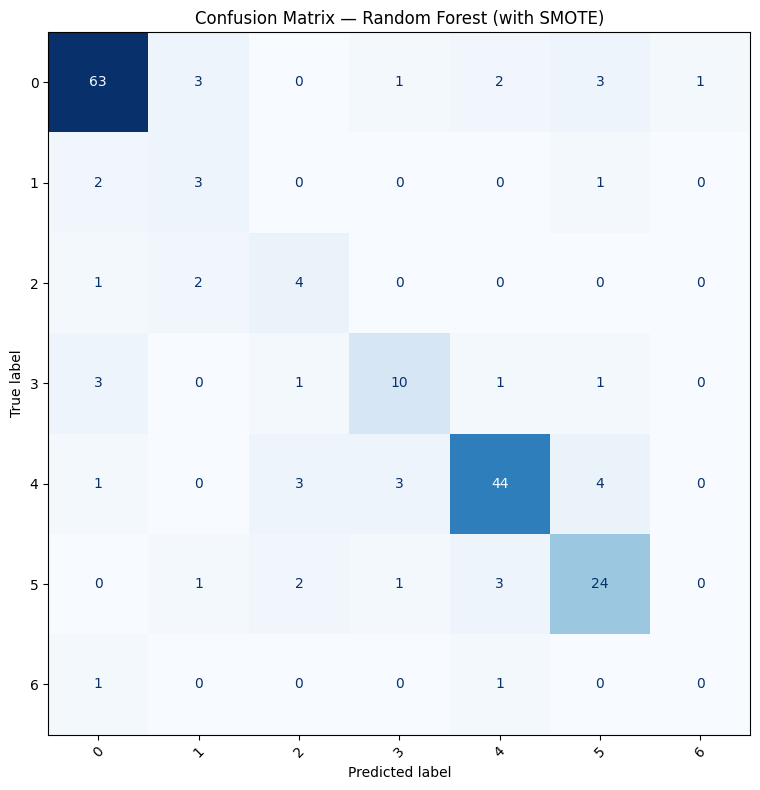

In [177]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf_fitted, rf_preds = evaluate_model(
    rf_model, "Random Forest",
    X_train, y_train, X_test, y_test,
    use_smote=True
)

## 12. XGBoost Classifier Model

XGBoost imported successfully.


  MODEL: XGBoost  (with SMOTE)

    5-Fold Cross-Validation (on training set)    
  Balanced Accuracy : 0.879 ± 0.012
  Macro F1          : 0.879 ± 0.012

    Test Set Performance    
  Accuracy          : 0.753
  Balanced Accuracy : 0.576
  Macro F1          : 0.564
  Weighted F1       : 0.760

    Full Classification Report    
              precision    recall  f1-score   support

           0       0.86      0.85      0.86        73
           1       0.33      0.50      0.40         6
           2       0.50      0.57      0.53         7
           3       0.67      0.62      0.65        16
           4       0.80      0.75      0.77        55
           5       0.74      0.74      0.74        31
           6       0.00      0.00      0.00         2

    accuracy                           0.75       190
   macro avg       0.56      0.58      0.56       190
weighted avg       0.77      0.75      0.76       190



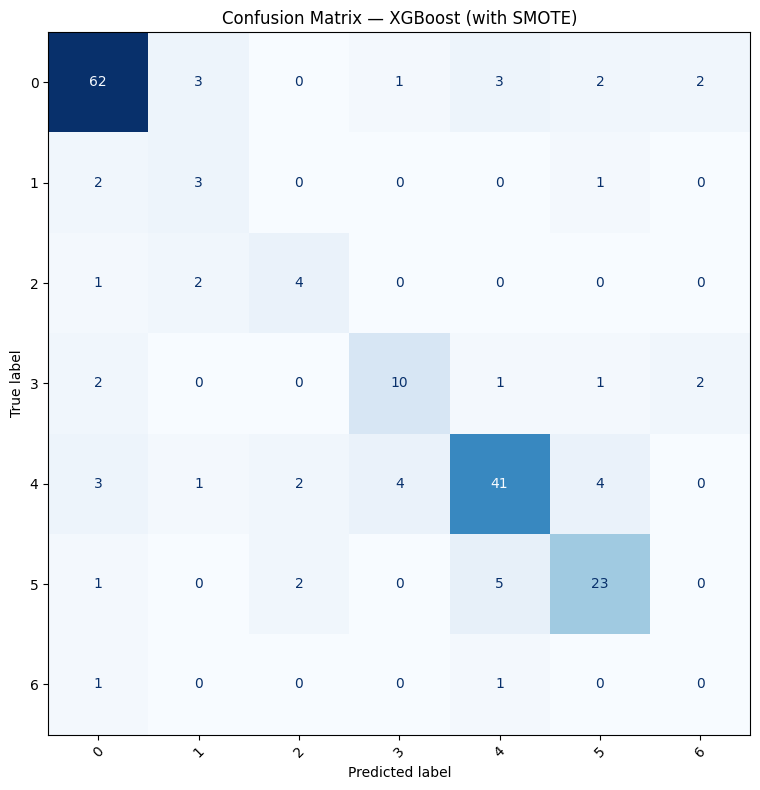

In [178]:
try:
    from xgboost import XGBClassifier
    print("XGBoost imported successfully.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier
    print("XGBoost installed and imported.")

# XGBoost requires class labels to be 0-indexed integers
# We remap y to ensure that
from sklearn.preprocessing import OrdinalEncoder
y_train_xgb = pd.Series(y_train).astype(int)
y_test_xgb  = pd.Series(y_test).astype(int)

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0,
    use_label_encoder=False
)

xgb_fitted, xgb_preds = evaluate_model(
    xgb_model, "XGBoost",
    X_train, y_train_xgb, X_test, y_test_xgb,
    use_smote=True
)

SHAP array shape: (190, 5, 7)


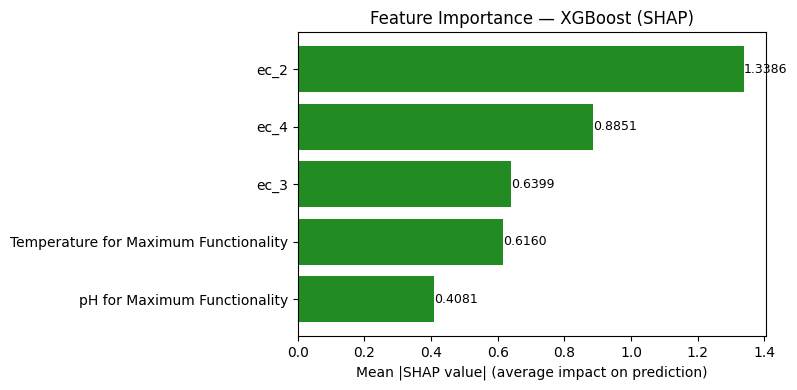


   Feature Importance Ranking (XGBoost — SHAP)    
                              Feature  Mean |SHAP|
                                 ec_2     1.338565
                                 ec_4     0.885058
                                 ec_3     0.639949
Temperature for Maximum Functionality     0.616042
         pH for Maximum Functionality     0.408128


In [179]:
# Create SHAP explainer
explainer_xgb = shap.TreeExplainer(xgb_fitted)

# Compute SHAP values
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Convert to numpy array for consistent handling
shap_array_xgb = np.array(shap_values_xgb)

print("SHAP array shape:", shap_array_xgb.shape)

# Mean absolute SHAP values across samples and classes
mean_shap_xgb = np.abs(shap_array_xgb).mean(axis=(0, 2))

# Build dataframe
shap_df_xgb = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': mean_shap_xgb
})

# Sort for plotting
shap_df_xgb = shap_df_xgb.sort_values(
    'Mean |SHAP|',
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    shap_df_xgb['Feature'],
    shap_df_xgb['Mean |SHAP|'],
    color='forestgreen'
)

ax.set_xlabel('Mean |SHAP value| (average impact on prediction)')
ax.set_title('Feature Importance — XGBoost (SHAP)', fontsize=12)

# Add SHAP value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.4f}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Print ranking
print("\n   Feature Importance Ranking (XGBoost — SHAP)    ")
print(
    shap_df_xgb.sort_values(
        'Mean |SHAP|',
        ascending=False
    ).to_string(index=False)
)

## 13. SMOTE Sensitivity Analysis



  MODEL: Random Forest  (without SMOTE)

    5-Fold Cross-Validation (on training set)    
  Balanced Accuracy : 0.602 ± 0.075
  Macro F1          : 0.621 ± 0.058

    Test Set Performance    
  Accuracy          : 0.795
  Balanced Accuracy : 0.573
  Macro F1          : 0.580
  Weighted F1       : 0.791

    Full Classification Report    
              precision    recall  f1-score   support

           0       0.83      0.88      0.85        73
           1       0.43      0.50      0.46         6
           2       0.50      0.43      0.46         7
           3       0.80      0.50      0.62        16
           4       0.87      0.84      0.85        55
           5       0.77      0.87      0.82        31
           6       0.00      0.00      0.00         2

    accuracy                           0.79       190
   macro avg       0.60      0.57      0.58       190
weighted avg       0.80      0.79      0.79       190



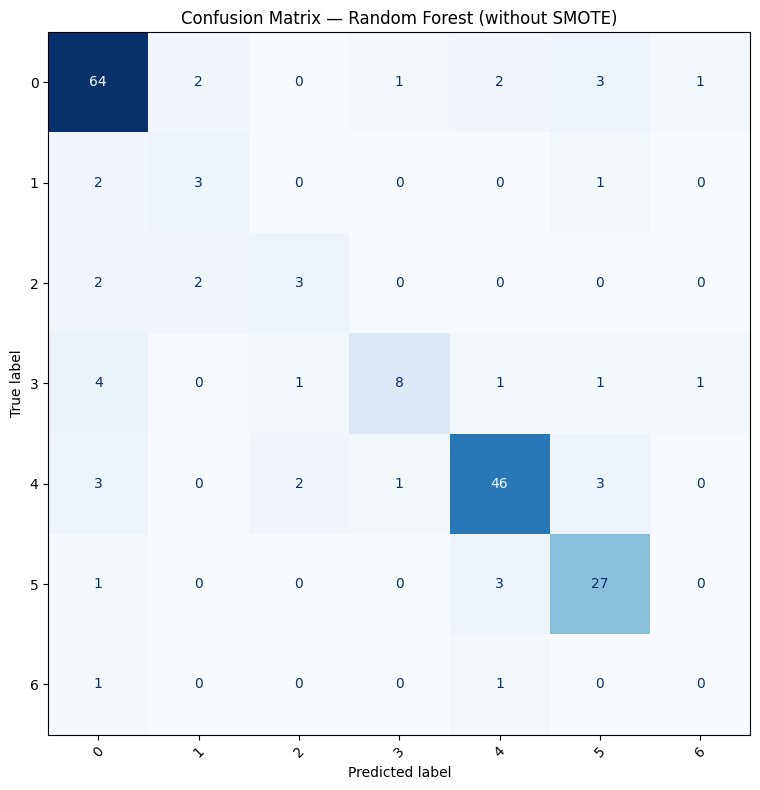

In [180]:
rf_no_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced'   # still use class_weight to handle imbalance
)

rf_no_smote_fitted, rf_no_smote_preds = evaluate_model(
    rf_no_smote, "Random Forest",
    X_train, y_train, X_test, y_test,
    use_smote=False            # key difference
)

In [181]:
# Summary table comparing with-SMOTE vs without-SMOTE for Random Forest
smote_acc     = accuracy_score(y_test, rf_preds)
smote_bacc    = balanced_accuracy_score(y_test, rf_preds)
smote_mf1     = f1_score(y_test, rf_preds, average='macro', zero_division=0)
smote_wf1     = f1_score(y_test, rf_preds, average='weighted', zero_division=0)

no_smote_acc  = accuracy_score(y_test, rf_no_smote_preds)
no_smote_bacc = balanced_accuracy_score(y_test, rf_no_smote_preds)
no_smote_mf1  = f1_score(y_test, rf_no_smote_preds, average='macro', zero_division=0)
no_smote_wf1  = f1_score(y_test, rf_no_smote_preds, average='weighted', zero_division=0)

summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Macro F1', 'Weighted F1'],
    'With SMOTE': [smote_acc, smote_bacc, smote_mf1, smote_wf1],
    'Without SMOTE': [no_smote_acc, no_smote_bacc, no_smote_mf1, no_smote_wf1],
})
summary_df['Difference'] = summary_df['With SMOTE'] - summary_df['Without SMOTE']
summary_df = summary_df.round(3)

print("    SMOTE Sensitivity Analysis — Random Forest    ")
print(summary_df.to_string(index=False))

    SMOTE Sensitivity Analysis — Random Forest    
           Metric  With SMOTE  Without SMOTE  Difference
         Accuracy       0.779          0.795      -0.016
Balanced Accuracy       0.591          0.573       0.017
         Macro F1       0.567          0.580      -0.013
      Weighted F1       0.783          0.791      -0.008


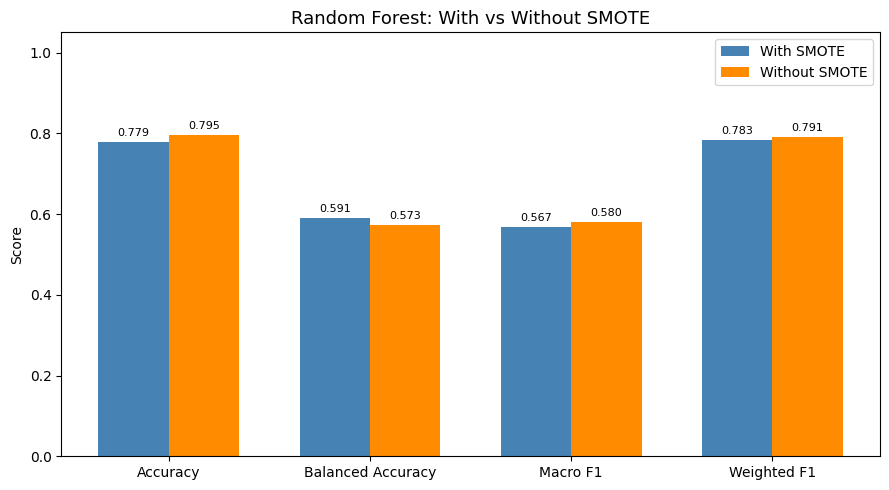

In [182]:
# Visual bar chart of the comparison
metrics = ['Accuracy', 'Balanced Accuracy', 'Macro F1', 'Weighted F1']
with_s    = [smote_acc, smote_bacc, smote_mf1, smote_wf1]
without_s = [no_smote_acc, no_smote_bacc, no_smote_mf1, no_smote_wf1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, with_s,    width, label='With SMOTE',    color='steelblue')
bars2 = ax.bar(x + width/2, without_s, width, label='Without SMOTE', color='darkorange')

ax.set_ylabel('Score')
ax.set_title('Random Forest: With vs Without SMOTE', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(bars1, padding=3, fmt='%.3f', fontsize=8)
ax.bar_label(bars2, padding=3, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

## 14. Model Comparison Summary

In [183]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

def scores(y_true, y_pred):
    return {
        'Accuracy'         : round(accuracy_score(y_true, y_pred), 3),
        'Balanced Accuracy': round(balanced_accuracy_score(y_true, y_pred), 3),
        'Macro F1'         : round(f1_score(y_true, y_pred, average='macro', zero_division=0), 3),
        'Weighted F1'      : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 3),
    }

comparison = pd.DataFrame([
    {'Model': 'Gradient Boosting', **scores(y_test, gb_preds)},
    {'Model': 'Random Forest',     **scores(y_test, rf_preds)},
    {'Model': 'XGBoost',           **scores(y_test_xgb, xgb_preds)},
]).set_index('Model')

print("=== Model Comparison Table (Test Set — with SMOTE) ===")
print(comparison.to_string())

=== Model Comparison Table (Test Set — with SMOTE) ===
                   Accuracy  Balanced Accuracy  Macro F1  Weighted F1
Model                                                                
Gradient Boosting     0.753              0.595     0.572        0.758
Random Forest         0.779              0.591     0.567        0.783
XGBoost               0.753              0.576     0.564        0.760


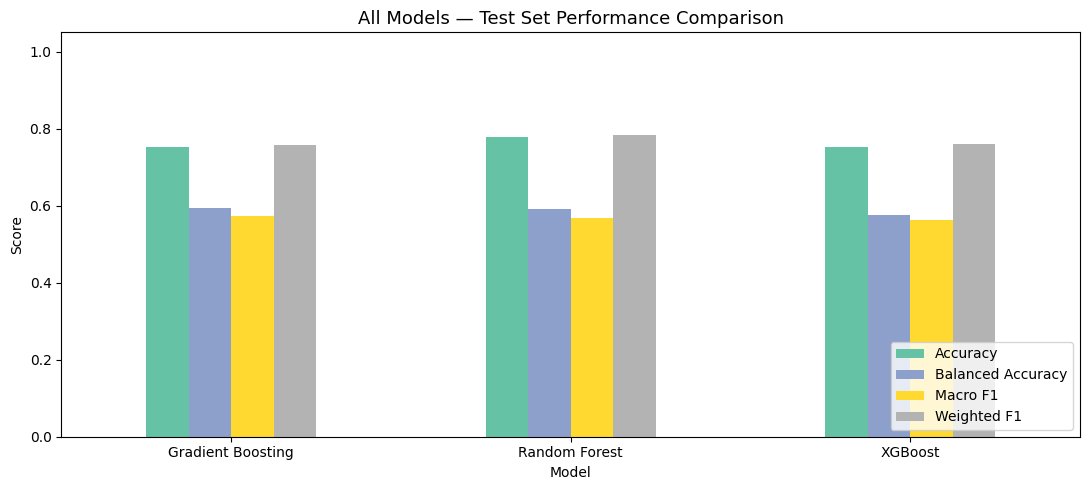

In [184]:
# Bar chart of all models side by side
comparison.plot(kind='bar', figsize=(11, 5), colormap='Set2')
plt.title('All Models — Test Set Performance Comparison', fontsize=13)
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 15. Feature Importance — SHAP Analysis

In [185]:
try:
    import shap
    shap.initjs()
    print("SHAP already installed.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap
    shap.initjs()
    print("SHAP installed and imported.")

SHAP already installed.


In [186]:
explainer_rf = shap.TreeExplainer(rf_fitted)

# Compute SHAP values on the test set (easier to interpret — these are truly unseen samples)
shap_values_rf = explainer_rf.shap_values(X_test.astype('float64'))

print("SHAP values computed.")
print(f"Shape of SHAP output: {np.array(shap_values_rf).shape}")
# For multi-class RF: shape is (n_classes, n_samples, n_features)

SHAP values computed.
Shape of SHAP output: (190, 5, 7)


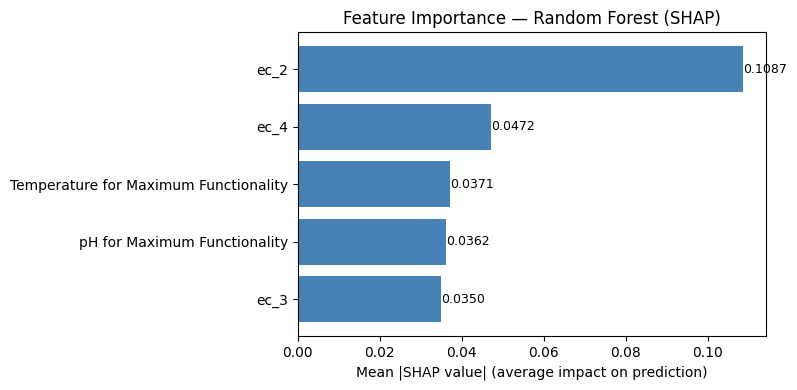


=== Feature Importance Ranking (Random Forest — SHAP) ===
                              Feature  Mean |SHAP|
                                 ec_2     0.108717
                                 ec_4     0.047245
Temperature for Maximum Functionality     0.037098
         pH for Maximum Functionality     0.036218
                                 ec_3     0.034996


In [187]:
# Global mean |SHAP| across all classes — bar plot
mean_shap = np.abs(shap_values_rf).mean(axis=(0, 2))

shap_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    shap_df['Feature'],
    shap_df['Mean |SHAP|'],
    color='steelblue'
)

ax.set_xlabel('Mean |SHAP value| (average impact on prediction)')
ax.set_title('Feature Importance — Random Forest (SHAP)', fontsize=12)


for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.4f}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("\n=== Feature Importance Ranking (Random Forest — SHAP) ===")
print(shap_df.sort_values('Mean |SHAP|', ascending=False).to_string(index=False))

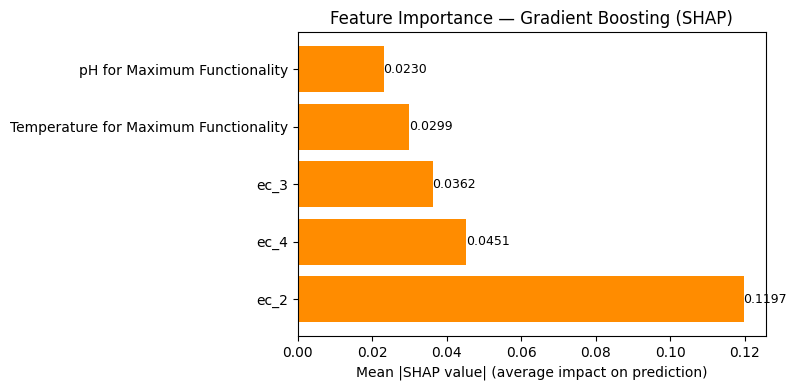

In [188]:
# Plotting the feature importance for Gradient Boosting
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    shap_df_gb['Feature'],
    shap_df_gb['Mean |SHAP|'],
    color='darkorange'
)

ax.set_xlabel('Mean |SHAP value| (average impact on prediction)')
ax.set_title('Feature Importance — Gradient Boosting (SHAP)', fontsize=12)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width,  # x-position (end of bar)
        bar.get_y() + bar.get_height() / 2,  # y-position (center of bar)
        f'{width:.4f}',  # label format
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()
plt.show()

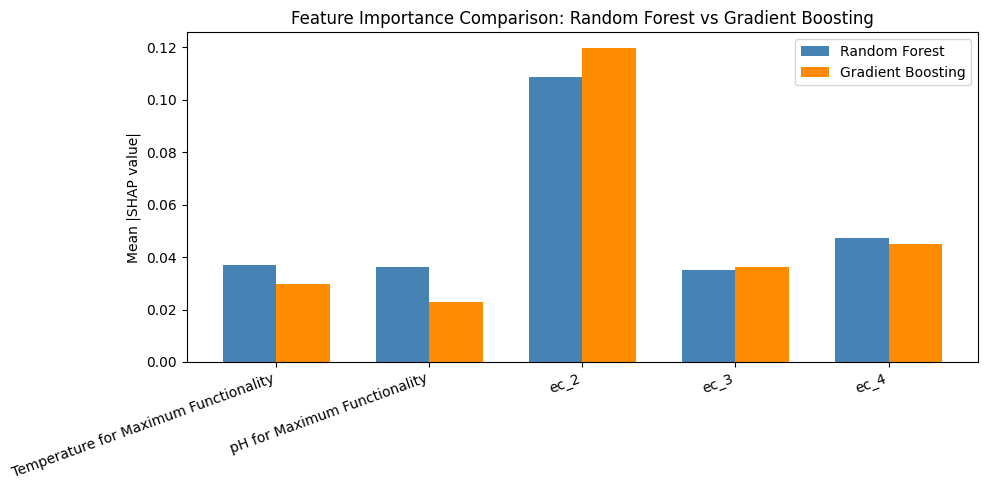

In [189]:
# Side-by-side comparison of feature importance: RF vs GB
features = X_test.columns.tolist()
shap_rf_vals = dict(zip(shap_df['Feature'], shap_df['Mean |SHAP|']))
shap_gb_vals = dict(zip(shap_df_gb['Feature'], shap_df_gb['Mean |SHAP|']))

rf_vals = [shap_rf_vals[f] for f in features]
gb_vals = [shap_gb_vals[f] for f in features]

x = np.arange(len(features))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, rf_vals, width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, gb_vals, width, label='Gradient Boosting', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=20, ha='right')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('Feature Importance Comparison: Random Forest vs Gradient Boosting', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()